<h1>LLM FINETUNING</h1>

<div style="background-color: #B8B8FF; color: black; padding: 10px">
    Finetuning
    <ul>
        <li>Adapting a pretrained model to a specific task by training the model on additional data.</li>
    </ul>
</div>

<div style="background-color: #B8B8FF; color: black; padding: 10px">
    <b>Instruction finetuning</b> : 
    <ul>
        <li>Trainig a language on a set of tasks using specific instruction.</li>
        <li>Can handle broader set of tasks.</li>
        <li>Larger datasets, greater computational power needed.</li>
        <li>Parameter Efficient Fine-Tuning (PEFT) : form of instruction fine-tuning that is much more efficient than full fine-tuning. 
            <ul>
                <li>Updating only a subset of parameters, effectively "freezing" the rest.</li>
                <li>This reuces the number of trainable parameters, making memory requirements more manageable and preventing catastrophic forgetting.</li>
                <li>Two methods:
                    <ul>
                        <li>LoRA : It is an improved finetunig method where instead of finetuning all the weights that constitute the weight matrix of the pre-trained large language model, two smaller matrices that approximate this larger matrix are fine-tuned.</li>
                        <li>QLoRA : Its is more memory-efficient iteration of LoRA. QLoRA takes LoRA a step further by also quantizing teh weights of the LoRA adapters (smaller matrices) to lower precision (eg, 4-bit instead of 8-bit).</li>
                    </ul> 
                </li>
            </ul>
        </li>
        <li>Illustration of instruction finetuning :</li>
    </ul>
</div>

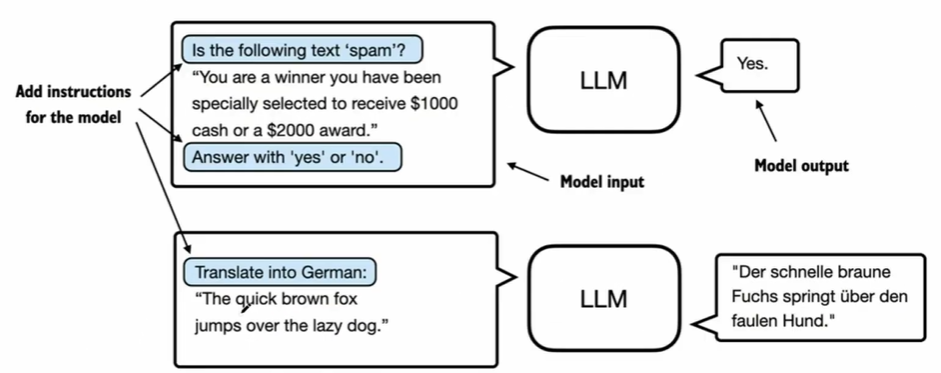

<div style="background-color: #B8B8FF; color: black; padding: 10px">
    <b>Classification finetuning</b> : 
    <ul>
        <li>Model is trained to recognise a specific set of class labels, such as spam or no spam</li>
        <li>Can handle narrow set of prompts.</li>
        <li>Illustration of classification finetuning :</li>
    <ul>
</div>

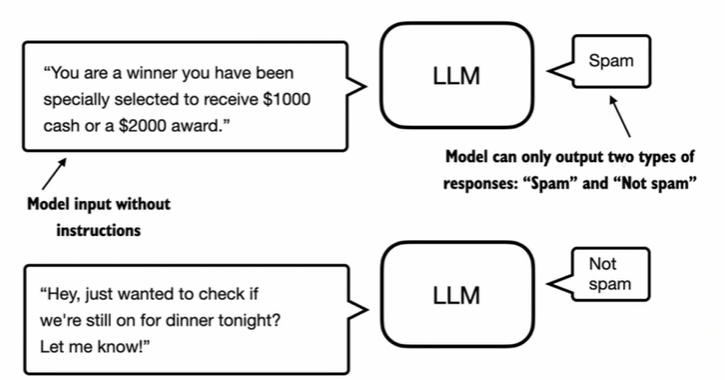

<h1>FINETUNING FOR CLASSIFICATION</h1>

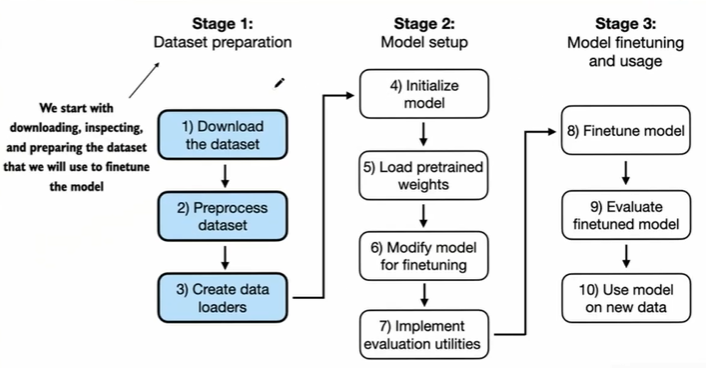

In [1]:
import tiktoken

tokenizer = tiktoken.get_encoding("gpt2")

<h3>DOWNLOADING DATASET</h3>

In [2]:
import urllib.request
import ssl
import zipfile
import os
from pathlib import Path

url = "https://archive.ics.uci.edu/static/public/228/sms+spam+collection.zip"
zip_path = "sms_spam_collection.zip"
extracted_path = "sms_spam_collection"
data_file_path = Path(extracted_path) / "SMSSpamCollection.tsv"

def download_and_unzip_spam_data(url, zip_path, extracted_path, data_file_path):
    if data_file_path.exists():
        print(f"{data_file_path} already exists. Skipping download and extraction.")
        return

    # Create an unverified SSL context
    ssl_context = ssl._create_unverified_context()

    # Downloading the file
    with urllib.request.urlopen(url, context=ssl_context) as response:
        with open(zip_path, "wb") as out_file:
            out_file.write(response.read())

    # Unzipping the file
    with zipfile.ZipFile(zip_path, "r") as zip_ref:
        zip_ref.extractall(extracted_path)

    # Add .tsv file extension
    original_file_path = Path(extracted_path) / "SMSSpamCollection"
    os.rename(original_file_path, data_file_path)
    print(f"File downloaded and saved as {data_file_path}")

download_and_unzip_spam_data(url, zip_path, extracted_path, data_file_path)

sms_spam_collection\SMSSpamCollection.tsv already exists. Skipping download and extraction.


<div style="background-color: #B8B8FF; color: black; padding: 10px">
    <ul>
        <li>After executing the preceding code, the dataset is saved as a tab-separated text file, SMSSpamCollection.tsv, in the sms_spam_collection folder.</li>
        <li>We can load it into a pandas DataFrame as follows:</li>
    </ul>
</div>

In [3]:
import pandas as pd

df = pd.read_csv(data_file_path, sep="\t", header=None, names=["Label", "Text"])
df

,Label,Text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."
...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...
5568,ham,Will ü b going to esplanade fr home?
5569,ham,"Pity, * was in mood for that. So...any other s..."
5570,ham,The guy did some bitching but I acted like i'd...


<div style="background-color: #B8B8FF; color: black; padding: 10px">
    When we check the class distribution, we see that the data contains "ham" (i.e., "not spam") much more frequently than "spam"
</div>

In [4]:
print(df["Label"].value_counts())

Label
ham     4825
spam     747
Name: count, dtype: int64


<div style="background-color: #B8B8FF; color: black; padding: 10px">   
    For simplicity, and because we prefer a small dataset for educational purposes anyway (it will make it possible to finetune the LLM faster), we subsample (undersample) the dataset so that it contains 747 instances from each class
</div>

In [5]:
def create_balanced_dataset(df):
    
    # Count the instances of "spam"
    num_spam = df[df["Label"] == "spam"].shape[0]
    
    # Randomly sample "ham" instances to match the number of "spam" instances
    ham_subset = df[df["Label"] == "ham"].sample(num_spam, random_state=123)
    
    # Combine ham "subset" with "spam"
    balanced_df = pd.concat([ham_subset, df[df["Label"] == "spam"]])

    return balanced_df

balanced_df = create_balanced_dataset(df)
print(balanced_df["Label"].value_counts())

Label
ham     747
spam    747
Name: count, dtype: int64


<div style="background-color: #B8B8FF; color: black; padding: 10px">
    <ul>
        <li>After executing the previous code to balance the dataset, we can see that we now have equal amounts of spam and non-spam messages:</li>
        <li>Next, we convert the "string" class labels "ham" and "spam" into integer class labels 0 and 1, respectively:</li>
    </ul>
</div>

In [6]:
balanced_df["Label"] = balanced_df["Label"].map({"ham": 0, "spam": 1})


<div style="background-color: #B8B8FF; color: black; padding: 10px">
    <ul>
        <li>This process is similar to converting text into token IDs.</li>
        <li>However, instead of using the GPT vocabulary, which consists of more than 50,000 words, we are dealing with just two token IDs: 0 and 1.</li>
    </ul>
</div>

<div style="background-color: #B8B8FF; color: black; padding: 10px">
    <ul>
        <li>We create a random_split function to split the dataset into three parts: 70% for training, 10% for validation, and 20% for testing.</li>
        <li>(These ratios are common in machine learning to train, adjust, and evaluate models.)</li>
    </ul>
</div>

In [7]:
def random_split(df, train_frac, validation_frac):
    # Shuffle the entire DataFrame
    df = df.sample(frac=1, random_state=123).reset_index(drop=True)

    # Calculate split indices
    train_end = int(len(df) * train_frac)
    validation_end = train_end + int(len(df) * validation_frac)

    # Split the DataFrame
    train_df = df[:train_end]
    validation_df = df[train_end:validation_end]
    test_df = df[validation_end:]

    return train_df, validation_df, test_df

train_df, validation_df, test_df = random_split(balanced_df, 0.7, 0.1)
# Test size is implied to be 0.2 as the remainder

print(len(train_df))
print(len(validation_df))
print(len(test_df))

1045
149
300


<div style="background-color: #B8B8FF; color: black; padding: 10px">
    Additionally, we save the dataset as CSV (comma-separated value) files, which we can reuse later:
</div>

In [8]:
train_df.to_csv("train.csv", index=None)
validation_df.to_csv("validation.csv", index=None)
test_df.to_csv("test.csv", index=None)

<h3>CREATING DATALOADERS</h3>

<div style="background-color: #B8B8FF; color: black; padding: 10px">
    Expected LLM output
</div>

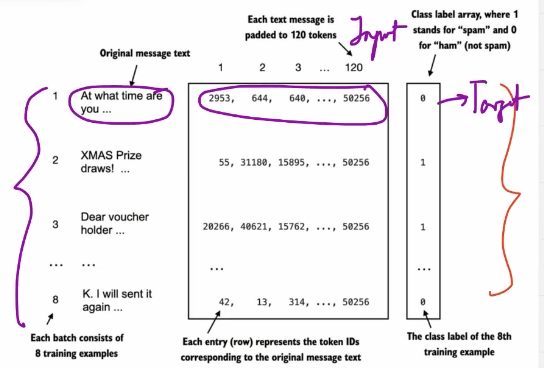

<div style="background-color: #B8B8FF; color: black; padding: 10px">
    <ul>
        <li>Previously, we utilized a sliding window technique to generate uniformly sized text chunks, which were then grouped into batches for more efficient model training. Each chunk functioned as an individual training instance</li>
        <li>In the case of email spam classification dataset, all the text messages are of varying length.</li>
        <li>To batch these messages all with same length we have two options :
            <ol>
                <li>Truncate all message to length of shortest message. (Not recommended at all coz it causes data loss)</li>
                <li>Pad all messages to length of longest message. (Recommended)</li>
            </ol>
        </li>
        <li>We'll append tokenId of "<|endoftext|>" (tokenId 50256) token to all other the messages to match the length of longest message.</li>
    </ul>
</div>

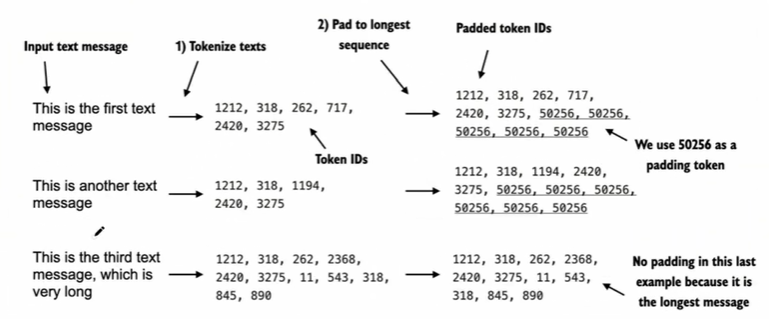

<div style="background-color: #B8B8FF; color: black; padding: 10px">
    <ul>
        <li>As we have seen earlier, we first need to implement a PyTorch Dataset, which specifies how the data is loaded and processed, before we can instantiate the data loaders.</li>
        <li>For this purpose, we define the SpamDataset class.</li>
        <li>This SpamDataset class handles several key tasks: it identifies the longest sequence in the training dataset, encodes the text messages, and ensures that all other sequences are padded with a padding token to match the length of the longest sequence.</li>
    </ul>
</div>

In [9]:
import torch
from torch.utils.data import Dataset

class SpamDataset(Dataset):
    def __init__(self, csv_file, tokenizer, max_length=None, pad_token_id=50256):
        self.data = pd.read_csv(csv_file)

        # Pre-tokenize texts
        self.encoded_texts = [
            tokenizer.encode(text) for text in self.data["Text"]
        ]

        if max_length is None:
            self.max_length = self._longest_encoded_length()
        else:
            self.max_length = max_length
            # Truncate sequences if they are longer than max_length
            self.encoded_texts = [
                encoded_text[:self.max_length]
                for encoded_text in self.encoded_texts
            ]

        # Pad sequences to the longest sequence
        self.encoded_texts = [
            encoded_text + [pad_token_id] * (self.max_length - len(encoded_text))
            for encoded_text in self.encoded_texts
        ]

    def __getitem__(self, index):
        encoded = self.encoded_texts[index]
        label = self.data.iloc[index]["Label"]
        return (
            torch.tensor(encoded, dtype=torch.long),
            torch.tensor(label, dtype=torch.long)
        )

    def __len__(self):
        return len(self.data)

    def _longest_encoded_length(self):
        max_length = 0
        for encoded_text in self.encoded_texts:
            encoded_length = len(encoded_text)
            if encoded_length > max_length:
                max_length = encoded_length
        return max_length

<div style="background-color: #B8B8FF; color: black; padding: 10px">
    <ul>
        <li>Step 1: Pre-tokenize texts</li>
        <li>Step 2: Truncate sequences if they are longer than max_length</li>
        <li>Step 3: Pad sequences to the longest sequence</li>
    </ul>
</div>

<div style="background-color: #B8B8FF; color: black; padding: 10px">
    <ul>
        <li>The SpamDataset class loads data from the CSV files we created earlier, tokenizes the text using the GPT-2 tokenizer from tiktoken and allows us to pad or truncate the sequences to a uniform length determined by either the longest sequence or a predefined maximum length.</li>
        <li>This ensures each input tensor is of the same size, which is necessary to create the batches in the training data loader we implement next:</li>
    </ul>
</div>

In [10]:
train_dataset = SpamDataset(
    csv_file="train.csv",
    max_length=None,
    tokenizer=tokenizer
)

print(train_dataset.max_length)

120


<div style="background-color: #B8B8FF; color: black; padding: 10px">
    <ul>
        <li>The code outputs 120, showing that the longest sequence contains no more than 120 tokens, a common length for text messages.</li>
        <li>It's worth noting that the model can handle sequences of up to 1,024 tokens, given its context length limit.</li>
        <li>If your dataset includes longer texts, you can pass max_length=1024 when creating the training dataset in the preceding code to ensure that the data does not exceed the model's supported input (context) length.</li>
        <li>Next, we pad the validation and test sets to match the length of the longest training sequence.</li>
        <li>It's important to note that any validation and test set samples exceeding the length of the longest training example are truncated using encoded_text[:self.max_length] in the SpamDataset code we defined earlier.</li>
        <li>This truncation is optional; you could also set max_length=None for both validation and test sets, provided there are no sequences exceeding 1,024 tokens in these sets</li>
    </ul>
</div>

In [11]:
val_dataset = SpamDataset(
    csv_file="validation.csv",
    max_length=train_dataset.max_length,
    tokenizer=tokenizer
)
test_dataset = SpamDataset(
    csv_file="test.csv",
    max_length=train_dataset.max_length,
    tokenizer=tokenizer
)

<div style="background-color: #B8B8FF; color: black; padding: 10px">
    <ul>
        <li>Using the datasets as inputs, we can instantiate the data loaders similarly to what we did earlier.</li>
        <li>However, in this case, the targets represent class labels rather than the next tokens in the text.</li>
        <li>For instance, choosing a batch size of 8, each batch will consist of 8 training examples of length 120 and the corresponding class label of each example.</li>
    </ul>
</div>

In [12]:
from torch.utils.data import DataLoader

num_workers = 0
batch_size = 8

torch.manual_seed(123)

train_loader = DataLoader(
    dataset=train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=num_workers,
    drop_last=True,
)

val_loader = DataLoader(
    dataset=val_dataset,
    batch_size=batch_size,
    num_workers=num_workers,
    drop_last=False,
)

test_loader = DataLoader(
    dataset=test_dataset,
    batch_size=batch_size,
    num_workers=num_workers,
    drop_last=False,
)

<div style="background-color: #B8B8FF; color: black; padding: 10px">
    To ensure that the data loaders are working and are indeed returning batches of the expected size, we iterate over the training loader and then print the tensor dimensions of the last batch:
</div>

In [13]:
print("Train loader:")
for input_batch, target_batch in train_loader:
    pass

print("Input batch dimensions:", input_batch.shape)
print("Label batch dimensions", target_batch.shape)

Train loader:
Input batch dimensions: torch.Size([8, 120])
Label batch dimensions torch.Size([8])


<div style="background-color: #B8B8FF; color: black; padding: 10px">
    <ul>
        <li>As we can see, the input batches consist of 8 training examples with 120 tokens each, as expected..</li>
        <li>The label tensor stores the class labels corresponding to the 8 training examples.</li>
        <li>Lastly, to get an idea of the dataset size, let's print the total number of batches in each dataset:</li>
    </ul>
</div>

In [14]:
print(f"{len(train_loader)} training batches")
print(f"{len(val_loader)} validation batches")
print(f"{len(test_loader)} test batches")

130 training batches
19 validation batches
38 test batches


<div style="background-color: #B8B8FF; color: black; padding: 10px">
    This concludes the data preparation. Next, we will prepare the model for finetuning.
</div>

<h3>INITIALIZING A MODEL WITH PRETRAINED WEIGHTS</h3>

<div style="background-color: #B8B8FF; color: black; padding: 10px">
    <ul>
        <li>In this section, we prepare the model we will use for the classification-finetuning to identify spam messages.</li>
        <li>We start with initializing the pretrained model we worked with in the previous chapter</li>
    </ul>
</div>

In [15]:
CHOOSE_MODEL = "gpt2-small (124M)"
INPUT_PROMPT = "Every effort moves"

BASE_CONFIG = {
    "vocab_size": 50257,     # Vocabulary size
    "context_length": 1024,  # Context length
    "drop_rate": 0.0,        # Dropout rate
    "qkv_bias": True         # Query-key-value bias
}

model_configs = {
    "gpt2-small (124M)": {"emb_dim": 768, "n_layers": 12, "n_heads": 12},
    "gpt2-medium (355M)": {"emb_dim": 1024, "n_layers": 24, "n_heads": 16},
    "gpt2-large (774M)": {"emb_dim": 1280, "n_layers": 36, "n_heads": 20},
    "gpt2-xl (1558M)": {"emb_dim": 1600, "n_layers": 48, "n_heads": 25},
}

BASE_CONFIG.update(model_configs[CHOOSE_MODEL])

assert train_dataset.max_length <= BASE_CONFIG["context_length"], (
    f"Dataset length {train_dataset.max_length} exceeds model's context "
    f"length {BASE_CONFIG['context_length']}. Reinitialize data sets with "
    f"`max_length={BASE_CONFIG['context_length']}`"
)

<div style="background-color: #B8B8FF; color: black; padding: 10px">
    <ul>
        <li>Next, we import the download_and_load_gpt function from the gpt_download3.py file we downloaded earlier.</li>
        <li>Furthermore, we also reuse the GPTModel class and load_weights_into_gpt function from chapter 5 to load the downloaded weights into the GPT model:</li>
    </ul>
</div>

In [16]:
from gpt_download3 import download_and_load_gpt2
from gptModel import GPTModel
from loadWeightsIntoGpt import load_weights_into_gpt
from generateTextByGptInvoke import generate_text_simple
from encoderAndDecoder import text_to_token_ids
from encoderAndDecoder import token_ids_to_text

In [17]:
model_size = CHOOSE_MODEL.split(" ")[-1].lstrip("(").rstrip(")")
print(model_size)

settings, params = download_and_load_gpt2(model_size=model_size, models_dir="gpt2")

model = GPTModel(BASE_CONFIG)
load_weights_into_gpt(model, params)
model.eval();

124M


e:\Anaconda\envs\learnllmfromscratch\Lib\site-packages\urllib3\connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'openaipublic.blob.core.windows.net'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(


File already exists and is up-to-date: gpt2\124M\checkpoint


e:\Anaconda\envs\learnllmfromscratch\Lib\site-packages\urllib3\connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'openaipublic.blob.core.windows.net'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(


File already exists and is up-to-date: gpt2\124M\encoder.json


...

File already exists and is up-to-date: gpt2\124M\model.ckpt.index


e:\Anaconda\envs\learnllmfromscratch\Lib\site-packages\urllib3\connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'openaipublic.blob.core.windows.net'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(


File already exists and is up-to-date: gpt2\124M\model.ckpt.meta


e:\Anaconda\envs\learnllmfromscratch\Lib\site-packages\urllib3\connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'openaipublic.blob.core.windows.net'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(


File already exists and is up-to-date: gpt2\124M\vocab.bpe


In [18]:
# To ensure that the model was loaded correctly, let's double-check that it generates coherent text

text_1 = "Every effort moves you"

token_ids = generate_text_simple(
    model=model,
    idx=text_to_token_ids(text_1, tokenizer),
    max_new_tokens=15,
    context_size=BASE_CONFIG["context_length"]
)

print(token_ids_to_text(token_ids, tokenizer))

Every effort moves you forward.

The first step is to understand the importance of your work


<div style="background-color: #B8B8FF; color: black; padding: 10px">
    Now, before we start finetuning the model as a spam classifier, let's see if the model can perhaps already classify spam messages by by prompting it with instructions:
</div>

In [19]:
text_2 = (
    "Is the following text 'spam'? Answer with 'yes' or 'no':"
    " 'You are a winner you have been specially"
    " selected to receive $1000 cash or a $2000 award.'"
)

token_ids = generate_text_simple(
    model=model,
    idx=text_to_token_ids(text_2, tokenizer),
    max_new_tokens=23,
    context_size=BASE_CONFIG["context_length"]
)

print(token_ids_to_text(token_ids, tokenizer))

Is the following text 'spam'? Answer with 'yes' or 'no': 'You are a winner you have been specially selected to receive $1000 cash or a $2000 award.'

The following text 'spam'? Answer with 'yes' or 'no': 'You are a winner


<div style="background-color: #B8B8FF; color: black; padding: 10px">
    <ul>
        <li>Based on the output, it's apparent that the model struggles with following instructions.</li>
        <li>This is anticipated, as it has undergone only pretraining and lacks instruction-finetuning, which we will explore in the upcoming chapter.</li>
        <li>The next section prepares the model for classification-finetuning</li>
    </ul>
</div>

<h3>ADDING A CLASSIFICATION HEAD</h3>

<div style="background-color: #B8B8FF; color: black; padding: 10px">
    Illustration for adding classification head :
</div>

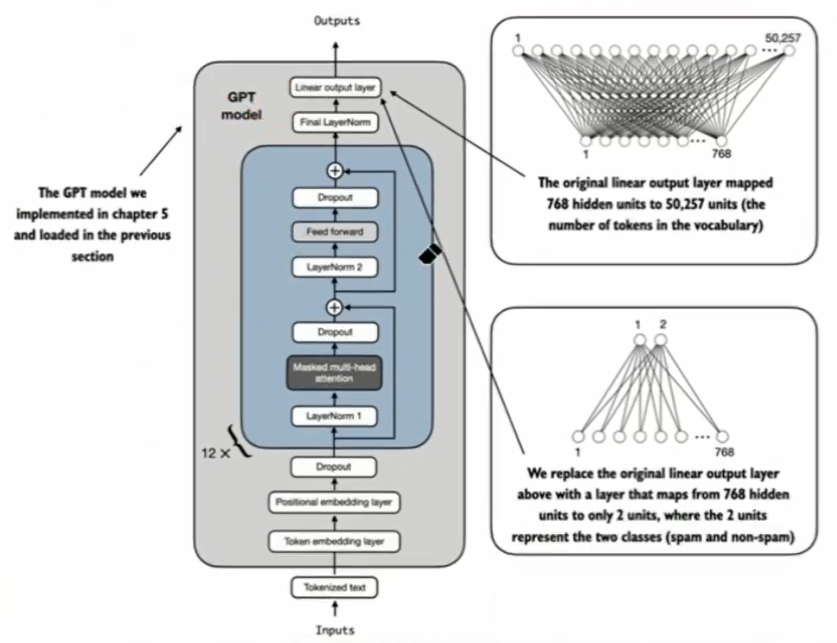

<div style="background-color: #B8B8FF; color: black; padding: 10px">
    <ul>
        <li>Our GPT model is built to generate next tokens equal to context_size (last linear output layer).</li>
        <li>To fulfill our reuirement in which we want 0 or 1 for either input is spam or not, we replace last linear layer (out_head) whose output for each tokenId is 0 or 1</li>
        <li>Select which layer we want to finetune.
            <ul>
                <li>Since we start with a pretrained model, it is not necessary to finetune all layers</li>
                <li>This is because the lower layers capture basic language structures and semantics, which are applicable across a wide range of tasks and dataset.</li>
                <li>Finetuning last layers is enought</li>
            </ul>
        </li>
        <li>We will finetune (We will freeze all other parameters):
            <ul>
                <li>Final output head</li>
                <li>Final transformer block</li>
                <li>Final layer normalization module</li>
            </ul>
        </li>
        <li>In last output layer output which contains logits for all tokenIds, logits of last tokenId is the answer we want. So we have to extract last output token row to depict whether the input is spam or not.</li>
    </ul>
</div>

<div style="background-color: #B8B8FF; color: black; padding: 10px">
    <ul>
        <li>In this section, we modify the pretrained large language model to prepare it for classification-finetuning.</li>
        <li>To do this, we replace the original output layer, which maps the hidden representation to a vocabulary of 50,257, with a smaller output layer that maps to two classes: 0 ("not spam") and 1 ("spam"),</li>
        <li>We could technically use a single output node since we are dealing with a binary classification task.</li>
        <li>However, this would require modifying the loss function.</li>
        <li>Therefore, we choose a more general approach where the number of output nodes matches the number of classes.</li>
        <li>For example, for a 3-class problem, such as classifying news articles as "Technology", "Sports", or "Politics", we would use three output nodes, and so forth.</li>
    </ul>
</div>

In [20]:
# Before we attempt to construct the modified architecture, let's print the model architecture via print(model), which prints the following:
print(model)

GPTModel(
  (tok_emb): Embedding(50257, 768)
  (pos_emb): Embedding(1024, 768)
  (drop_emb): Dropout(p=0.0, inplace=False)
  (trf_blocks): Sequential(
    (0): TransformerBlock(
      (att): MultiHeadAttention(
        (w_query): Linear(in_features=768, out_features=768, bias=True)
        (w_key): Linear(in_features=768, out_features=768, bias=True)
        (w_value): Linear(in_features=768, out_features=768, bias=True)
        (out_proj): Linear(in_features=768, out_features=768, bias=True)
        (dropout): Dropout(p=0.0, inplace=False)
      )
      (ff): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU()
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (drop_shortcut): Dropout(p=0.0, inplace=False)
    )
    (1): TransformerBlock(
      (att): MultiHeadAttention(
        (w_query): Linear(in_features=7

<div style="background-color: #B8B8FF; color: black; padding: 10px">
    <ul>
        <li>Above, we can see the GPT architecture neatly laid out.</li>
        <li>As discussed earlier, the GPTModel consists of embedding layers followed by 12 identical transformer blocks (only the last block is shown for brevity), followed by a final LayerNorm and the output layer, out_head.</li>
        <li>Next, we replace the out_head with a new output layer, as illustrated in figure 6.9, that we will finetune.</li>
    </ul>
</div>

<div style="background-color: #B8B8FF; color: black; padding: 10px">
    To get the model ready for classification-finetuning, we first freeze the model, meaning that we make all layers non-trainable:
</div>

In [21]:
for param in model.parameters():
    param.requires_grad = False

<div style="background-color: #B8B8FF; color: black; padding: 10px">
    Then, we replace the output layer (model.out_head), which originally maps the layer inputs to 50,257 dimensions (the size of the vocabulary):
</div>

In [22]:
torch.manual_seed(123)

num_classes = 2
model.out_head = torch.nn.Linear(in_features=BASE_CONFIG["emb_dim"], out_features=num_classes)

<div style="background-color: #B8B8FF; color: black; padding: 10px">
    <ul>
        <li>Note that in the preceding code, we use BASE_CONFIG["emb_dim"], which is equal to 768 in the "gpt2-small (124M)" model, to keep the code below more general.</li>
        <li>This means we can also use the same code to work with the larger GPT-2 model variants.</li>
        <li>This new model.out_head output layer has its requires_grad attribute set to True by default, which means that it's the only layer in the model that will be updated during training.</li>
        <li>Additionally, we configure the last transformer block and the final LayerNorm module, which connects this block to the output layer, to be trainable.</li>
    </ul>
</div>

In [23]:
for param in model.trf_blocks[-1].parameters():
    param.requires_grad = True

for param in model.final_norm.parameters():
    param.requires_grad = True

<div style="background-color: #B8B8FF; color: black; padding: 10px">
    <ul>
        <li>Even though we added a new output layer and marked certain layers as trainable or nontrainable, we can still use this model in a similar way to previous chapters.</li>
        <li>For instance, we can feed it an example text identical to how we have done it in earlier chapters. For example, consider the following example text:</li>
    </ul>
</div>

In [24]:
inputs = tokenizer.encode("Do you have time")
inputs = torch.tensor(inputs).unsqueeze(0)
print("Inputs:", inputs)
print("Inputs dimensions:", inputs.shape) # shape: (batch_size, num_tokens)

Inputs: tensor([[5211,  345,  423,  640]])
Inputs dimensions: torch.Size([1, 4])


<div style="background-color: #B8B8FF; color: black; padding: 10px">
    Then, we can pass the encoded token IDs to the model as usual:
</div>

In [25]:
with torch.no_grad():
    outputs = model(inputs)

print("Outputs:\n", outputs)
print("Outputs dimensions:", outputs.shape) # shape: (batch_size, num_tokens, num_classes)

Outputs:
 tensor([[[-1.5854,  0.9904],
         [-3.7235,  7.4548],
         [-2.2661,  6.6049],
         [-3.5983,  3.9902]]])
Outputs dimensions: torch.Size([1, 4, 2])


<div style="background-color: #B8B8FF; color: black; padding: 10px">
    <ul>
        <li>In earlier chapters, a similar input would have produced an output tensor of [1, 4, 50257], where 50,257 represents the vocabulary size.</li>
        <li>As in previous chapters, the number of output rows corresponds to the number of input tokens (in this case, 4).</li>
        <li>However, each output's embedding dimension (the number of columns) is now reduced to 2 instead of 50,257 since we replaced the output layer of the model.</li>
        <li>Remember that we are interested in finetuning this model so that it returns a class label that indicates whether a model input is spam or not spam.</li>
        <li>To achieve this, we don't need to finetune all 4 output rows but can focus on a single output token.</li>
        <li>In particular, we will focus on the last row corresponding to the last output token.</li>
        <li>Values of last token is still random as our model is still not trained on our dataset</li>
    </ul>
</div>

In [26]:
# extract last row.
# second parameter is -1 as we want last token

print("Last output token:", outputs[:, -1, :])

Last output token: tensor([[-3.5983,  3.9902]])


<div style="background-color: #B8B8FF; color: black; padding: 10px">
    <ul>
        <li>Having modified the model, the next section will detail the process of transforming the last token into class label predictions and calculate the model's initial prediction accuracy.</li>
        <li>Following this, we will finetune the model for the spam classification task in the subsequent section.</li>
    </ul>
</div>

<h3>CALCULATING THE CLASSIFICATION LOSS AND ACCURACY</h3>

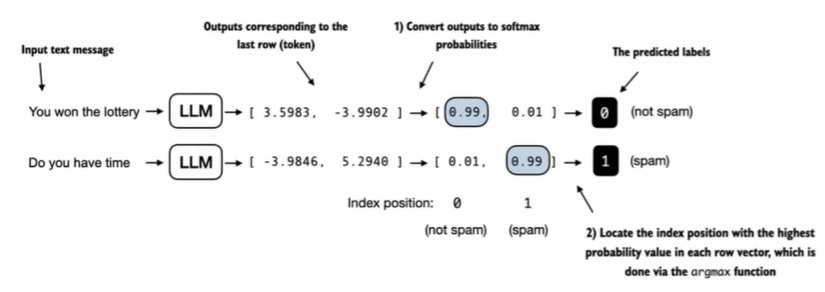

<div style="background-color: #B8B8FF; color: black; padding: 10px">
    <ul>
        <li>So far in this chapter, we have prepared the dataset, loaded a pretrained model, and modified it for classification-finetuning.</li>
        <li>Before we proceed with the finetuning itself, only one small part remains: implementing the model evaluation functions used during finetuning.</li>
        <li>Before implementing the evaluation utilities, let's briefly discuss how we convert the model outputs into class label predictions.</li>
        <li>In the previous chapter, we computed the token ID of the next token generated by the LLM by converting the 50,257 outputs into probabilities via the softmax function and then returning the position of the highest probability via the argmax function.</li>
        <li>In this chapter, we take the same approach to calculate whether the model outputs a "spam" or "not spam" prediction for a given input, with the only difference being that we work with 2-dimensional instead of 50,257-dimensional outputs.</li>
    </ul>
</div>

In [27]:
# Let's consider the last token output from the previous section:
print("Last output token:", outputs[:, -1, :])

Last output token: tensor([[-3.5983,  3.9902]])


In [28]:
# We can obtain the class label via the following code:

probas = torch.softmax(outputs[:, -1, :], dim=-1)
label = torch.argmax(probas)
print("Class label:", label.item())

Class label: 1


<div style="background-color: #B8B8FF; color: black; padding: 10px">
    <ul>
        <li>In this case, the code returns 1, meaning the model predicts that the input text is "spam."</li>
        <li>Using the softmax function here is optional because the largest outputs directly correspond to the highest probability scores.</li>
        <li>Hence, we can simplify the code as follows, without using softmax:</li>
    </ul>
</div>

In [34]:
logits = outputs[:, -1, :]
label = torch.argmax(logits)
print(label)
print("Class label:", label.item())

tensor(1)
Class label: 1


<div style="background-color: #B8B8FF; color: black; padding: 10px">
    <ul>
        <li>This concept can be used to compute the so-called classification accuracy, which measures the percentage of correct predictions across a dataset.</li>
        <li>To determine the classification accuracy, we apply the argmax-based prediction code to all examples in the dataset and calculate the proportion of correct predictions by defining a calc_accuracy_loader function:</li>
    </ul>
</div>

In [41]:
def calc_accuracy_loader(data_loader, model, device, num_batches=None):
    model.eval()
    correct_predictions, num_examples = 0, 0

    if num_batches is None:
        num_batches = len(data_loader)
    else:
        num_batches = min(num_batches, len(data_loader))
    for i, (input_batch, target_batch) in enumerate(data_loader):
        if i < num_batches:
            input_batch, target_batch = input_batch.to(device), target_batch.to(device)

            with torch.no_grad():
                logits = model(input_batch)[:, -1, :]  # Logits of last output token
            predicted_labels = torch.argmax(logits, dim=-1)

            num_examples += predicted_labels.shape[0]
            correct_predictions += (predicted_labels == target_batch).sum().item()
        else:
            break
    return correct_predictions / num_examples

<div style="background-color: #B8B8FF; color: black; padding: 10px">
    Let's use the function to determine the classification accuracies across various datasets estimated from 10 batches for efficiency:
</div>

In [42]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Note:
# Uncommenting the following lines will allow the code to run on Apple Silicon chips, if applicable,
# which is approximately 2x faster than on an Apple CPU (as measured on an M3 MacBook Air).
# As of this writing, in PyTorch 2.4, the results obtained via CPU and MPS were identical.
# However, in earlier versions of PyTorch, you may observe different results when using MPS.

#if torch.cuda.is_available():
#    device = torch.device("cuda")
#elif torch.backends.mps.is_available():
#    device = torch.device("mps")
#else:
#    device = torch.device("cpu")
#print(f"Running on {device} device.")

model.to(device) # no assignment model = model.to(device) necessary for nn.Module classes

torch.manual_seed(123) # For reproducibility due to the shuffling in the training data loader

train_accuracy = calc_accuracy_loader(train_loader, model, device, num_batches=10)
val_accuracy = calc_accuracy_loader(val_loader, model, device, num_batches=10)
test_accuracy = calc_accuracy_loader(test_loader, model, device, num_batches=10)

print(f"Training accuracy: {train_accuracy*100:.2f}%")
print(f"Validation accuracy: {val_accuracy*100:.2f}%")
print(f"Test accuracy: {test_accuracy*100:.2f}%")

Training accuracy: 46.25%
Validation accuracy: 45.00%
Test accuracy: 48.75%


<div style="background-color: #B8B8FF; color: black; padding: 10px">
    <ul>
        <li>As we can see, the prediction accuracies are near a random prediction, which would be 50% in this case.</li>
        <li>To improve the prediction accuracies, we need to finetune the model.</li>
    </ul>
</div>

<div style="background-color: #B8B8FF; color: black; padding: 10px">
    <ul>
        <li>Classification accuracy is not a differentiable function, so we use cross entropy loss as a proxy to maximize accuracy.</li>
        <li>This is the same cross entropy loss discussed earlier.</li>
        <li>Accordingly, the calc_loss_batch function remains the same as in earlier, with one adjustment: we focus on optimizing only the last token, model(input_batch)[:, -1, :], rather than all tokens, model(input_batch):</li>
    </ul>
</div>

In [53]:
def calc_loss_batch(input_batch, target_batch, model, device):
    input_batch, target_batch = input_batch.to(device), target_batch.to(device)
    # target batch shape : [8] 8 rows for 8 tokens and 1 row for actual value
    output = model(input_batch) # Shape = [8, 120, 2]
    logits = output[:, -1, :]  # Logits of last output token, Shape : [8, 2]
    loss = torch.nn.functional.cross_entropy(logits, target_batch)
    return loss

<div style="background-color: #B8B8FF; color: black; padding: 10px">
    We use the calc_loss_batch function to compute the loss for a single batch obtained from the previously defined data loaders. To calculate the loss for all batches in a data loader, we define the calc_loss_loader function
</div>

In [46]:
# Same as in chapter 5
def calc_loss_loader(data_loader, model, device, num_batches=None):
    total_loss = 0.
    if len(data_loader) == 0:
        return float("nan")
    elif num_batches is None:
        num_batches = len(data_loader)
    else:
        # Reduce the number of batches to match the total number of batches in the data loader
        # if num_batches exceeds the number of batches in the data loader
        num_batches = min(num_batches, len(data_loader))
    for i, (input_batch, target_batch) in enumerate(data_loader):
        if i < num_batches:
            loss = calc_loss_batch(input_batch, target_batch, model, device)
            total_loss += loss.item()
        else:
            break
    return total_loss / num_batches

In [54]:
# Similar to calculating the training accuracy, we now compute the initial loss for each data set:

with torch.no_grad(): # Disable gradient tracking for efficiency because we are not training, yet
    train_loss = calc_loss_loader(train_loader, model, device, num_batches=5)
    val_loss = calc_loss_loader(val_loader, model, device, num_batches=5)
    test_loss = calc_loss_loader(test_loader, model, device, num_batches=5)

print(f"Training loss: {train_loss:.3f}")
print(f"Validation loss: {val_loss:.3f}")
print(f"Test loss: {test_loss:.3f}")

Training loss: 2.194
Validation loss: 2.583
Test loss: 2.322


<div style="background-color: #B8B8FF; color: black; padding: 10px">
    <ul>
        <li>In the next section, we will implement a training function to finetune the model, which means adjusting the model to minimize the training set loss.</li>
        <li>Minimizing the training set loss will help increase the classification accuracy, our overall goal.</li>
    </ul>
</div>

<h3>FINETUNING THE MODEL ON SUPERVISED DATA</h3>

<div style="background-color: #B8B8FF; color: black; padding: 10px">
    Illustration of training loop
</div>

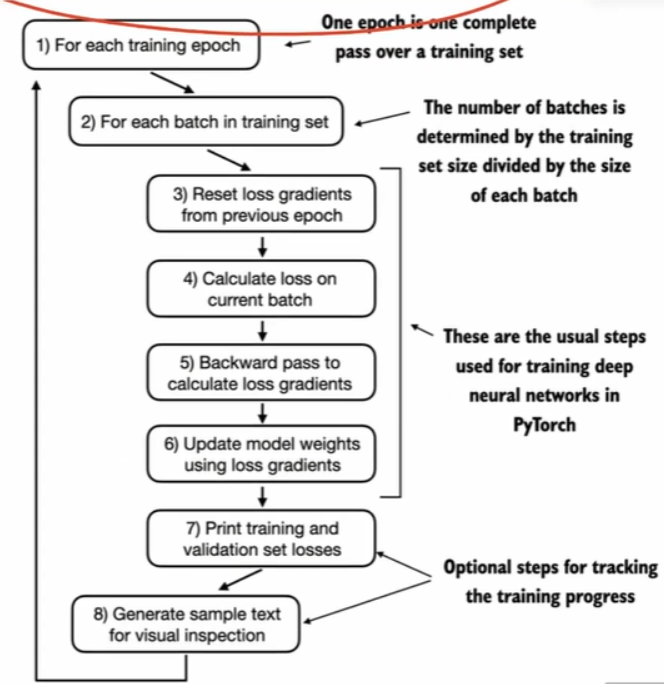

<div style="background-color: #B8B8FF; color: black; padding: 10px">
    <ul>
        <li>In this section, we define and use the training function to finetune the pretrained LLM and improve its spam classification accuracy.</li>
        <li>The training loop is the same overall training loop we used earlier, with the only difference being that we calculate the classification accuracy instead of generating a sample text for evaluating the model.</li>
        <li>The training function also closely mirrors the train_model_simple function used for pretraining the model earlier.</li>
        <li>The only two distinctions are that we now track the number of training examples seen (examples_seen) instead of the number of tokens, and we calculate the accuracy after each epoch instead of printing a sample text:</li>
    </ul>
</div>

<div style="background-color: #B8B8FF; color: black; padding: 10px">
    <ul>
        <li>Step 1: Set model to training mode</li>
        <li>Step 2: Reset loss gradients from previous batch iteration</li>
        <li>Step 3: Calculate loss gradients</li>
        <li>Step 4: Update model weights using loss gradients</li>
        <li>Step 5: <b>New</b>: track examples instead of tokens</li>
        <li>Step 6: Optional evaluation step</li>
        <li>Step 7: Calculate accuracy after each epoch</li>
    </ul>
</div>

In [58]:
# Overall the same as `train_model_simple` in chapter llmPretraining
def train_classifier_simple(model, train_loader, val_loader, optimizer, device, num_epochs,
                            eval_freq, eval_iter):
    # Initialize lists to track losses and examples seen
    train_losses, val_losses, train_accs, val_accs = [], [], [], []
    examples_seen, global_step = 0, -1

    # Main training loop
    for epoch in range(num_epochs):
        model.train()  # Set model to training mode

        for input_batch, target_batch in train_loader:
            optimizer.zero_grad() # Reset loss gradients from previous batch iteration
            loss = calc_loss_batch(input_batch, target_batch, model, device)
            loss.backward() # Calculate loss gradients
            optimizer.step() # Update model weights using loss gradients
            #example_seen is incremented for each text message
            examples_seen += input_batch.shape[0] # New: track examples instead of tokens
            global_step += 1

            #130 batches : training, eval_Freq=50 --> after 50 batches are processed in each epoch, we print

            # Optional evaluation step
            if global_step % eval_freq == 0:
                train_loss, val_loss = evaluate_model(
                    model, train_loader, val_loader, device, eval_iter)
                train_losses.append(train_loss)
                val_losses.append(val_loss)
                print(f"Ep {epoch+1} (Step {global_step:06d}): "
                      f"Train loss {train_loss:.3f}, Val loss {val_loss:.3f}")

        # Calculate accuracy after each epoch
        train_accuracy = calc_accuracy_loader(train_loader, model, device, num_batches=eval_iter)
        val_accuracy = calc_accuracy_loader(val_loader, model, device, num_batches=eval_iter)
        print(f"Training accuracy: {train_accuracy*100:.2f}% | ", end="")
        print(f"Validation accuracy: {val_accuracy*100:.2f}%")
        train_accs.append(train_accuracy)
        val_accs.append(val_accuracy)

    return train_losses, val_losses, train_accs, val_accs, examples_seen

In [57]:
# The evaluate_model function used in the train_classifier_simple is the same as the one we used earlier.

# Same as chapter 5
def evaluate_model(model, train_loader, val_loader, device, eval_iter):
    model.eval()
    with torch.no_grad():
        train_loss = calc_loss_loader(train_loader, model, device, num_batches=eval_iter)
        val_loss = calc_loss_loader(val_loader, model, device, num_batches=eval_iter)
    model.train()
    return train_loss, val_loss

<div style="background-color: #B8B8FF; color: black; padding: 10px">
    <ul>
        <li>Next, we initialize the optimizer, set the number of training epochs, and initiate the training using the train_classifier_simple function.</li>
        <li>We will discuss the choice of the the number of training epochs after we evaluated the results.</li>
        <li>The training takes about 6 minutes on an M3 MacBook Air laptop computer and less than half a minute on a V100 or A100 GPU:</li>
    </ul>
</div>

In [59]:
import time

start_time = time.time()

torch.manual_seed(123)

optimizer = torch.optim.AdamW(model.parameters(), lr=5e-5, weight_decay=0.1)

num_epochs = 5
train_losses, val_losses, train_accs, val_accs, examples_seen = train_classifier_simple(
    model, train_loader, val_loader, optimizer, device,
    num_epochs=num_epochs, eval_freq=50, eval_iter=5,
)

end_time = time.time()
execution_time_minutes = (end_time - start_time) / 60
print(f"Training completed in {execution_time_minutes:.2f} minutes.")

Ep 1 (Step 000000): Train loss 2.153, Val loss 2.392
Ep 1 (Step 000050): Train loss 0.617, Val loss 0.637
Ep 1 (Step 000100): Train loss 0.523, Val loss 0.557
Training accuracy: 70.00% | Validation accuracy: 72.50%
Ep 2 (Step 000150): Train loss 0.561, Val loss 0.489
Ep 2 (Step 000200): Train loss 0.419, Val loss 0.397
Ep 2 (Step 000250): Train loss 0.409, Val loss 0.353
Training accuracy: 82.50% | Validation accuracy: 85.00%
Ep 3 (Step 000300): Train loss 0.333, Val loss 0.320
Ep 3 (Step 000350): Train loss 0.340, Val loss 0.306
Training accuracy: 90.00% | Validation accuracy: 90.00%
Ep 4 (Step 000400): Train loss 0.136, Val loss 0.200
Ep 4 (Step 000450): Train loss 0.153, Val loss 0.132
Ep 4 (Step 000500): Train loss 0.222, Val loss 0.137
Training accuracy: 100.00% | Validation accuracy: 97.50%
Ep 5 (Step 000550): Train loss 0.207, Val loss 0.143
Ep 5 (Step 000600): Train loss 0.083, Val loss 0.074
Training accuracy: 100.00% | Validation accuracy: 97.50%
Training completed in 36.45 m

<div style="background-color: #B8B8FF; color: black; padding: 10px">
    We then use matplotlib to plot the loss function for the training and validation set:
</div>

In [60]:
import matplotlib.pyplot as plt

def plot_values(epochs_seen, examples_seen, train_values, val_values, label="loss"):
    fig, ax1 = plt.subplots(figsize=(5, 3))

    # Plot training and validation loss against epochs
    ax1.plot(epochs_seen, train_values, label=f"Training {label}")
    ax1.plot(epochs_seen, val_values, linestyle="-.", label=f"Validation {label}")
    ax1.set_xlabel("Epochs")
    ax1.set_ylabel(label.capitalize())
    ax1.legend()

    # Create a second x-axis for examples seen
    ax2 = ax1.twiny()  # Create a second x-axis that shares the same y-axis
    ax2.plot(examples_seen, train_values, alpha=0)  # Invisible plot for aligning ticks
    ax2.set_xlabel("Examples seen")

    fig.tight_layout()  # Adjust layout to make room
    plt.savefig(f"{label}-plot.pdf")
    plt.show()

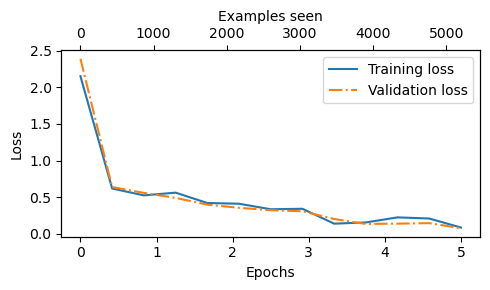

In [61]:
epochs_tensor = torch.linspace(0, num_epochs, len(train_losses))
examples_seen_tensor = torch.linspace(0, examples_seen, len(train_losses))

plot_values(epochs_tensor, examples_seen_tensor, train_losses, val_losses)

<div style="background-color: #B8B8FF; color: black; padding: 10px">
    As we can see based on the sharp downward slope, the model is learning well from the training data, and there is little to no indication of overfitting; that is, there is no noticeable gap between the training and validation set losses).
</div>

<div style="background-color: #B8B8FF; color: black; padding: 10px">
    Using the same plot_values function, let's now also plot the classification accuracies:
</div>

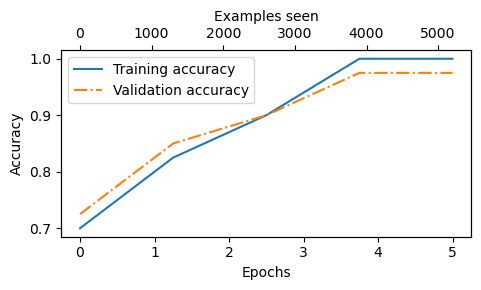

In [62]:
epochs_tensor = torch.linspace(0, num_epochs, len(train_accs))
examples_seen_tensor = torch.linspace(0, examples_seen, len(train_accs))

plot_values(epochs_tensor, examples_seen_tensor, train_accs, val_accs, label="accuracy")

<div style="background-color: #B8B8FF; color: black; padding: 10px">
    <ul>
        <li>Based on the accuracy plot in figure 6.17, the model achieves a relatively high training and validation accuracy after epochs 4 and 5.</li>
        <li>However, it's important to note that we previously set eval_iter=5 when using the train_classifier_simple function, which means our estimations of training and validation performance were based on only 5 batches for efficiency during training.</li>
        <li>Now, we will calculate the performance metrics for the training, validation, and test sets across the entire dataset by running the following code, this time without defining the eval_iter value:</li>
    </ul>
</div>

In [63]:
train_accuracy = calc_accuracy_loader(train_loader, model, device)
val_accuracy = calc_accuracy_loader(val_loader, model, device)
test_accuracy = calc_accuracy_loader(test_loader, model, device)

print(f"Training accuracy: {train_accuracy*100:.2f}%")
print(f"Validation accuracy: {val_accuracy*100:.2f}%")
print(f"Test accuracy: {test_accuracy*100:.2f}%")

Training accuracy: 97.21%
Validation accuracy: 97.32%
Test accuracy: 95.67%


<div style="background-color: #B8B8FF; color: black; padding: 10px">
    <ul>
        <li>The training and test set performances are almost identical.</li>
        <li>A slight discrepancy between the training and test set accuracies suggests minimal overfitting of the training data.</li>
        <li>Typically, the validation set accuracy is somewhat higher than the test set accuracy because the model development often involves tuning hyperparameters to perform well on the validation set, which might not generalize as effectively to the test set.</li>
        <li>This situation is common, but the gap could potentially be minimized by adjusting the model's settings, such as increasing the dropout rate (drop_rate) or the weight_decay parameter in the optimizer configuration.</li>
    </ul>
</div>

<h3>USING THE LLM AS A SPAM CLASSIFIER</h3>

<div style="background-color: #B8B8FF; color: black; padding: 10px">
    <ul>
        <li>After finetuning and evaluating the model in the previous sections, we are now in the final stage of this chapter: using the model to classify spam messages.</li>
        <li>Finally, let's use the finetuned GPT-based spam classification model.</li>
        <li>The following classify_review function follows data preprocessing steps similar to those we used in the SpamDataset implemented earlier in this chapter.</li>
        <li>And then, after processing text into token IDs, the function uses the model to predict an integer class label, similar to what we have implemented earlier, and then returns the corresponding class name:</li>
    </ul>
</div>

<div style="background-color: #B8B8FF; color: black; padding: 10px">
    <ul>
        <li>Step 1: Prepare inputs to the model</li>
        <li>Step 2: Truncate sequences if they too long</li>
        <li>Step 3: Pad sequences to the longest sequence</li>
        <li>Step 4: Add batch dimension</li>
        <li>Step 5: Model inference without gradient tracking</li>
        <li>Step 6: Logits of the last output token</li>
        <li>Step 7: Return the classified result</li>
    </ul>
</div>

In [64]:
def classify_review(text, model, tokenizer, device, max_length=None, pad_token_id=50256):
    model.eval()

    # Prepare inputs to the model
    input_ids = tokenizer.encode(text)
    supported_context_length = model.pos_emb.weight.shape[0]
    # Note: In the book, this was originally written as pos_emb.weight.shape[1] by mistake
    # It didn't break the code but would have caused unnecessary truncation (to 768 instead of 1024)

    # Truncate sequences if they too long
    input_ids = input_ids[:min(max_length, supported_context_length)]

    # Pad sequences to the longest sequence
    input_ids += [pad_token_id] * (max_length - len(input_ids))
    input_tensor = torch.tensor(input_ids, device=device).unsqueeze(0) # add batch dimension

    # Model inference
    with torch.no_grad():
        logits = model(input_tensor)[:, -1, :]  # Logits of the last output token
    predicted_label = torch.argmax(logits, dim=-1).item()

    # Return the classified result
    return "spam" if predicted_label == 1 else "not spam"

<div style="background-color: #B8B8FF; color: black; padding: 10px">
    Let's try this classify_review function on an example text:
</div>

In [65]:
text_1 = (
    "You are a winner you have been specially"
    " selected to receive $1000 cash or a $2000 award."
)

print(classify_review(
    text_1, model, tokenizer, device, max_length=train_dataset.max_length
))

spam


<div style="background-color: #B8B8FF; color: black; padding: 10px">
    The resulting model correctly predicts "spam".
</div>

In [66]:
text_2 = (
    "Hey, just wanted to check if we're still on"
    " for dinner tonight? Let me know!"
)

print(classify_review(
    text_2, model, tokenizer, device, max_length=train_dataset.max_length
))

not spam


<div style="background-color: #B8B8FF; color: black; padding: 10px">
    Also, here, the model makes a correct prediction and returns a "not spam" label.
</div>

<div style="background-color: #B8B8FF; color: black; padding: 10px">
    Finally, let's save the model in case we want to reuse the model later without having to train it again using the torch.save method
</div>

In [67]:
torch.save(model.state_dict(), "review_classifier.pth")

<div style="background-color: #B8B8FF; color: black; padding: 10px">
    Once saved, the model can be loaded as follows:
</div>

In [ ]:
model_state_dict = torch.load("review_classifier.pth")
model.load_state_dict(model_state_dict) 

<All keys matched successfully>